# Intro für Machine Learning: Supervised Learning mit DRP-Daten

Dieses Notebook ist ein Kurs zu **supervised learning** anhand eines synthetischen, klinisch plausiblen Datensatzes zur **diabetischen Retinopathie (DRP)**.

Wir haben einen mit folgenden Variablen:

- Alter
- HbA1c
- Diabetesdauer
- Cholesterin
- systolischer Blutdruck
- Visus
- Metamorphopsien
- Diabetestyp

---

> **Merke**  
> In diesem Kurs arbeiten wir ausschließlich mit **supervised learning**.  
> Das bedeutet: Die Zielwerte sind bereits bekannt, und das Modell lernt, diese für neue Daten vorherzusagen.

## Lernziele
Am Ende dieses Notebooks kannst du:

1. supervised und unsupervised learning unterscheiden
2. Features und Target benennen
3. einen Datensatz explorieren und visualisieren
4. `train_test_split` methodisch korrekt erklären
5. KNN für Klassifikation einsetzen
6. Underfitting und Overfitting erkennen
7. ein Regressionsproblem formulieren
8. lineare Regression, Ridge und Lasso vergleichen

## Einordnung: Beispiele für Machine Learning

Machine Learning bedeutet, dass ein Modell Muster aus Daten lernt.

Beispiele:
- Vorhersage, ob eine E-Mail Spam oder nicht Spam ist
- Gruppierung von Büchern nach ähnlichem Inhalt
- Vorhersage, ob bei einer Person eine Erkrankung vorliegt
- Vorhersage eines kontinuierlichen Werts, z. B. eines Scores oder Messwerts

### Unsupervised Learning
Beim **unsupervised learning** gibt es **keine bekannten Zielwerte**. Das Modell versucht, verborgene Muster oder Strukturen in unlabelten Daten zu erkennen.

Beispiel:
- Patient:innen anhand ähnlicher klinischer Profile gruppieren, ohne vorher festzulegen, welche Gruppen existieren

### Supervised Learning
Beim **supervised learning** sind die Zielwerte bereits bekannt. Das Modell lernt eine Beziehung zwischen **Features** und **Target** und soll diese später auf neue, unbekannte Daten anwenden.

In diesem Notebook konzentrieren wir uns ausschließlich auf supervised learning.

> **Achtung**  
> Ein Modell, das auf Trainingsdaten gut funktioniert, ist noch nicht automatisch ein gutes Modell.  
> Entscheidend ist, wie gut es auf **neue, ungesehene Daten** generalisiert.

## Zwei Typen von supervised learning

### 1. Klassifikation
Hier wird eine **Kategorie** vorhergesagt.

Beispiel:
- DRP vorhanden: ja / nein

Wenn es genau zwei Klassen gibt, sprechen wir von **binärer Klassifikation**.

### 2. Regression
Hier wird ein **kontinuierlicher Wert** vorhergesagt.

Beispiel:
- ein klinischer Risikoscore
- eine zentrale Netzhautdicke
- ein kontinuierlicher Schweregradwert

---

> 💬 **Begriffe**  
> **Features** = Eingangsvariablen  
> **Target** = Zielvariable  
> In anderer Literatur findest du auch: predictor variables, independent variables, response variable, dependent variable.

## Bevor supervised learning startet

Vor dem Training müssen Daten geeignet aufbereitet sein:

- möglichst keine fehlenden Werte
- numerische oder sinnvoll encodierte Eingaben
- tabellarische Struktur, z. B. als pandas DataFrame
- Exploration mit deskriptiven Statistiken und Visualisierungen

Gerade bei Distanz-basierten Modellen wie KNN ist **Feature-Skalierung** wichtig, weil große Zahlenbereiche sonst die Distanz dominieren.

In [442]:
# ============================================
# Setup
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_auc_score, RocCurveDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso

np.random.seed(42)
pd.set_option("display.max_columns", 100)

# 1. Datensatz erzeugen

Wir erstellen einen **synthetischen**, aber klinisch plausiblen Datensatz zur DRP.

## Features
- `age`
- `hba1c`
- `duration_dm`
- `cholesterol`
- `sbp`
- `visual_acuity`
- `metamorphopsia`
- `diabetes_type`

## Targets
- `drp` → binäre Klassifikation
- `retina_risk_score` → Regression


In [443]:
import numpy as np
import pandas as pd

np.random.seed(42)

def logit(p):
    return np.log(p / (1 - p))

def expit(x):
    return 1 / (1 + np.exp(-x))

def make_drp_dataset(n=2000, save_csv=False, filename="drp_dataset.csv"):
    rows = []

    # Kalibrierung:
    # Typ 1: P(DRP | duration=20) ~ 0.99
    # Typ 2: P(DRP | duration=20) ~ 0.25
    # Wir modellieren zuerst eine basis-dauerabhängige Wahrscheinlichkeit,
    # danach kommen kleinere metabolische Korrekturen auf der Logit-Skala.
    max_p_t1 = 0.995
    tau_t1 = -20 / np.log(1 - 0.99 / max_p_t1) # tau so wählen, dass bei 20 Jahren die gewünschte Wahrscheinlichkeit erreicht wird

    max_p_t2 = 0.60
    tau_t2 = -20 / np.log(1 - 0.25 / max_p_t2)

    for _ in range(n):
        diabetes_type = np.random.choice(["Typ 1", "Typ 2"], p=[0.25, 0.75]) # p für realistischere Verteilung

        if diabetes_type == "Typ 1":
            # Typ 1: Manifestation überwiegend im Kindes-/Jugendalter
            onset_age = np.random.randint(1, 21)  # garantiert: age - duration <= 20
            max_duration = 85 - onset_age
            duration_dm = np.random.randint(0, min(45, max_duration) + 1)
            age = onset_age + duration_dm

            # Metabolisch im Mittel besser eingestellt
            hba1c = np.clip(np.random.normal(7.4, 1.0), 5.2, 12.5) # clip für realistischere Werte
            sbp = np.clip(np.random.normal(122, 12), 95, 180) # realistischere Werte
            cholesterol = np.clip(np.random.normal(178, 28), 110, 300) # realistischere Werte

            # Dauer = dominanter Faktor
            base_p = max_p_t1 * (1 - np.exp(-duration_dm / tau_t1))

            # Kleine metabolische Modulation
            adj = (
                0.10 * (hba1c - 7.0) +
                0.010 * (sbp - 120) +
                0.004 * (cholesterol - 180)
            )

        else:
            # Typ 2: spätere Manifestation
            onset_age = np.random.randint(30, 71)
            max_duration = 90 - onset_age
            duration_dm = np.random.randint(0, min(35, max_duration) + 1)
            age = onset_age + duration_dm

            # Metabolisch im Mittel schlechter eingestellt
            hba1c = np.clip(np.random.normal(8.2, 1.1), 5.5, 13.5)
            sbp = np.clip(np.random.normal(144, 16), 100, 210)
            cholesterol = np.clip(np.random.normal(220, 35), 130, 360)

            # Dauer = dominanter Faktor
            base_p = max_p_t2 * (1 - np.exp(-duration_dm / tau_t2))

            # Kleine bis moderate metabolische Modulation
            adj = (
                0.14 * (hba1c - 7.0) +
                0.012 * (sbp - 130) +
                0.005 * (cholesterol - 200)
            )

        # Basiswahrscheinlichkeit + Modulation auf Logit-Skala
        # Clip verhindert numerische Probleme
        base_p = np.clip(base_p, 1e-4, 1 - 1e-4)
        drp_prob = expit(logit(base_p) + adj + np.random.normal(0, 0.15))

        drp = np.random.binomial(1, drp_prob)

        # Visus: bei DRP tendenziell schlechter, zusätzlich leichte Dauerabhängigkeit
        visual_acuity = np.clip(
            np.random.normal(
                0.95 - 0.20 * drp - 0.006 * duration_dm,
                0.12
            ),
            0.05,
            1.2
        )

        # Metamorphopsien: bei DRP häufiger, aber nicht deterministisch
        metamorphopsia_prob = np.clip(
            0.03 + 0.22 * drp + 0.03 * (visual_acuity < 0.5),
            0.01,
            0.75
        )
        metamorphopsia = np.random.binomial(1, metamorphopsia_prob)

        # Kontinuierlicher Score für Regressionsaufgaben
        # Dauer bleibt hier ebenfalls der stärkste Treiber
        retina_risk_score = (
            10
            + 3.2 * duration_dm
            + 5.0 * drp
            + 1.3 * (hba1c - 7.0)
            + 0.10 * (sbp - 130)
            + 0.04 * (cholesterol - 200)
            - 10.0 * visual_acuity
            + 4.0 * metamorphopsia
            + np.random.normal(0, 6)
        )

        rows.append({
            "age": int(age),
            "hba1c": round(float(hba1c), 2),
            "duration_dm": int(duration_dm),
            "cholesterol": round(float(cholesterol), 1),
            "sbp": round(float(sbp), 1),
            "visual_acuity": round(float(visual_acuity), 2),
            "metamorphopsia": int(metamorphopsia),
            "diabetes_type": diabetes_type,
            "drp_prob": round(float(drp_prob), 4),
            "drp": int(drp),
            "retina_risk_score": round(float(retina_risk_score), 2)
        })

    df = pd.DataFrame(rows)

    if save_csv:
        df.to_csv(filename, index=False)

    return df

df = make_drp_dataset(n=2000, save_csv=True, filename="drp_dataset.csv")
df.head()

# 1) Typ-1-Bedingung prüfen
t1 = df[df["diabetes_type"] == "Typ 1"].copy()
print("Max(age - duration_dm) bei Typ 1:", (t1["age"] - t1["duration_dm"]).max())

# 2) Erwartete DRP-Wahrscheinlichkeit bei 20 Jahren Dauer
check = (
    df.groupby(["diabetes_type", "duration_dm"])["drp_prob"]
      .mean()
      .reset_index()
)

print(check.query("diabetes_type == 'Typ 1' and duration_dm == 20"))
print(check.query("diabetes_type == 'Typ 2' and duration_dm == 20"))

# 3) Grober metabolischer Vergleich
summary = (
    df.groupby("diabetes_type")[["hba1c", "sbp", "cholesterol", "duration_dm", "drp_prob"]]
      .mean()
      .round(2)
)
print(summary)

Max(age - duration_dm) bei Typ 1: 20
   diabetes_type  duration_dm  drp_prob
20         Typ 1           20  0.991218
   diabetes_type  duration_dm  drp_prob
66         Typ 2           20  0.373828
               hba1c     sbp  cholesterol  duration_dm  drp_prob
diabetes_type                                                   
Typ 1           7.47  122.53       178.93        22.81      0.92
Typ 2           8.20  144.60       218.58        16.14      0.27


# 2. Erste Exploration und Visualisierung

Bevor wir trainieren, überprüfen wir:
- Datentypen
- fehlende Werte
- Verteilungen
- Unterschiede zwischen Klassen

> **Merke**  
> Gute ML-Projekte beginnen nicht mit dem Modell, sondern mit dem **Verstehen der Daten**. Deswegen ist die interdisziplinäre Zusammenarbeit bei medizinischen Datensätzen so wichtig.

In [444]:
df.info()
print("\nFehlende Werte pro Spalte:\n")
print(df.isna().sum())

print("\nDeskriptive Statistik:\n")
display(df.describe(include="all"))

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                2000 non-null   int64  
 1   hba1c              2000 non-null   float64
 2   duration_dm        2000 non-null   int64  
 3   cholesterol        2000 non-null   float64
 4   sbp                2000 non-null   float64
 5   visual_acuity      2000 non-null   float64
 6   metamorphopsia     2000 non-null   int64  
 7   diabetes_type      2000 non-null   str    
 8   drp_prob           2000 non-null   float64
 9   drp                2000 non-null   int64  
 10  retina_risk_score  2000 non-null   float64
dtypes: float64(6), int64(4), str(1)
memory usage: 172.0 KB

Fehlende Werte pro Spalte:

age                  0
hba1c                0
duration_dm          0
cholesterol          0
sbp                  0
visual_acuity        0
metamorphopsia       0
diabetes_type        0
drp_pro

,age,hba1c,duration_dm,cholesterol,sbp,visual_acuity,metamorphopsia,diabetes_type,drp_prob,drp,retina_risk_score
count,2000.000000,2000.000000,2000.00000,2000.00000,2000.000000,2000.000000,2000.000000,2000,2000.000000,2000.00000,2000.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Typ 2,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1476,NaN,NaN,NaN
mean,57.494000,8.007500,17.88750,208.18885,138.814550,0.752695,0.133500,NaN,0.441454,0.45450,65.201035
std,20.036484,1.130785,11.15944,37.64402,17.795636,0.183835,0.340199,NaN,0.325966,0.49805,38.256674
min,2.000000,5.200000,0.00000,110.00000,95.000000,0.170000,0.000000,NaN,0.000100,0.00000,-11.880000
25%,44.000000,7.240000,8.00000,182.00000,126.100000,0.620000,0.000000,NaN,0.198875,0.00000,33.425000
50%,60.000000,8.025000,17.00000,206.95000,138.600000,0.760000,0.000000,NaN,0.350450,0.00000,62.995000
75%,73.000000,8.790000,26.00000,233.22500,151.525000,0.890000,0.000000,NaN,0.588500,1.00000,93.250000


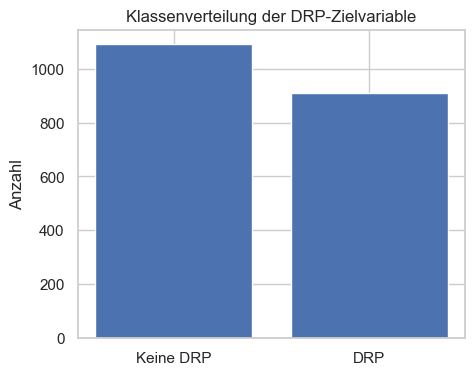

In [445]:
# ============================================
# Visualisierung 1: Klassenverteilung
# ============================================
class_counts = df["drp"].value_counts().sort_index()

plt.figure(figsize=(5,4))
plt.bar(["Keine DRP", "DRP"], class_counts.values)
plt.title("Klassenverteilung der DRP-Zielvariable")
plt.ylabel("Anzahl")
plt.show()

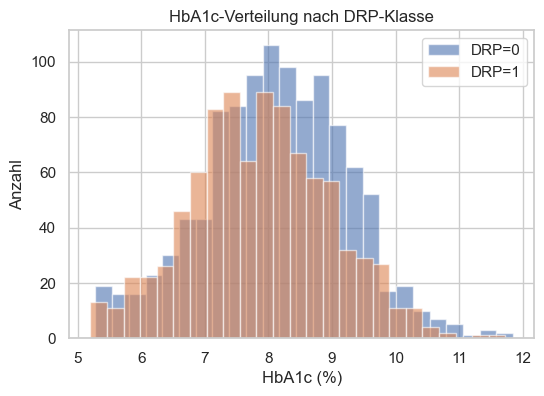

In [446]:
# ============================================
# Visualisierung 2: HbA1c nach DRP-Klasse
# ============================================
plt.figure(figsize=(6,4))
for label in [0, 1]:
    subset = df[df["drp"] == label]["hba1c"]
    plt.hist(subset, bins=25, alpha=0.6, label=f"DRP={label}")

plt.title("HbA1c-Verteilung nach DRP-Klasse")
plt.xlabel("HbA1c (%)")
plt.ylabel("Anzahl")
plt.legend()
plt.show()

## Gruppendiskussion: HbA1c

1. Wie plausibel ist die beobachtete Beziehung zwischen HbA1c und DRP aus klinischer Sicht? 
    - not plausible: If we set a threshold with 6.5% then < 50% of patients developt DRP. 

2. Welche wichtigen Risikofaktoren fehlen in dieser Darstellung noch?
    - alle anderen: dauer, sbp, cholesterin. 

3. Würdest du erwarten, dass HbA1c allein ein guter Prädiktor ist? Warum (nicht)?
    - Kein guter Prädiktor, weil die wahrscheinlichkeit von DRP mit Diabetes ist unter 50%, aber zum Vergleich wahrscheinlich ja. 

4. In der Praxis zeigen Menschen, die ihren Blutzucker rasant verbessern häufig eine Verschlechterung des Befundus. Wie würdest du dir das pathophysiologisch erklären?
    - Blutzucker ist nicht der einziger Prädiktor der  DRP-Entstehung; Senkung der Compliance. 

> **Deine Antwort:**  
> Schreibe deine Antworten in die nächste Zelle.

In [447]:
# Schreibe hier deine Antworten zur Gruppendiskussion


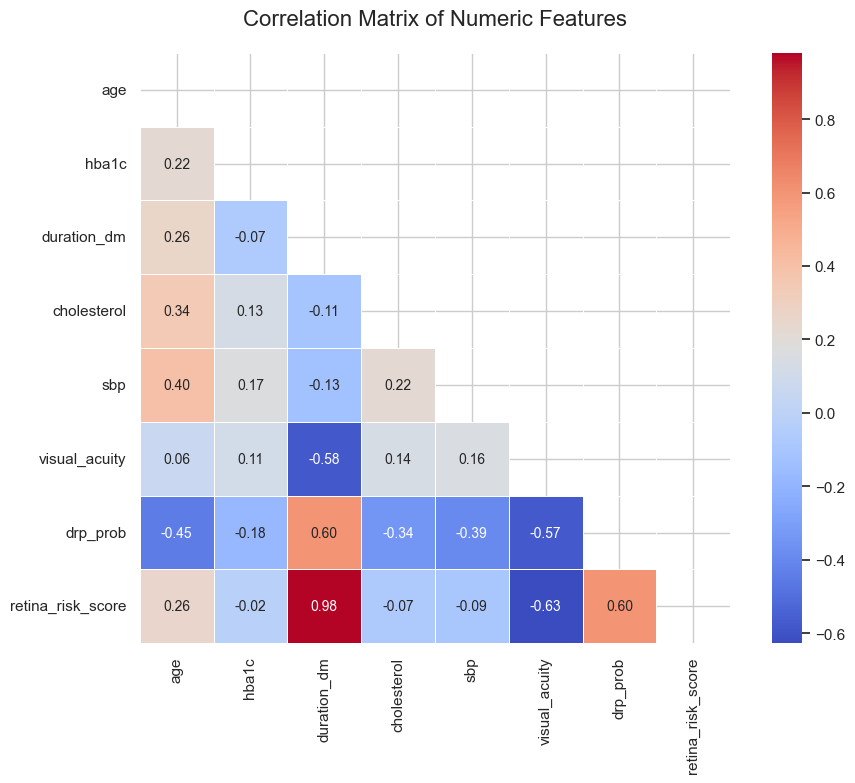

In [448]:
import seaborn as sns

import numpy as np
import matplotlib.pyplot as plt

# Mask the upper triangle
numeric_features = ["age", "hba1c", "duration_dm", "cholesterol", "sbp", "visual_acuity", "drp_prob", "retina_risk_score"]
correlation_matrix = df[numeric_features].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Create a heatmap with the mask applied
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    mask=mask,  # Apply the mask
    annot=True,  # Display correlation values
    fmt=".2f",   # Format the values to 2 decimal places
    cmap="coolwarm",  # Color map
    cbar=True,  # Show color bar
    square=True,  # Make cells square
    linewidths=0.5,  # Add lines between cells
    annot_kws={"size": 10}  # Adjust annotation font size
)

# Add a title
plt.title("Correlation Matrix of Numeric Features", fontsize=16, pad=20)

# Show the plot
plt.tight_layout()
plt.show()


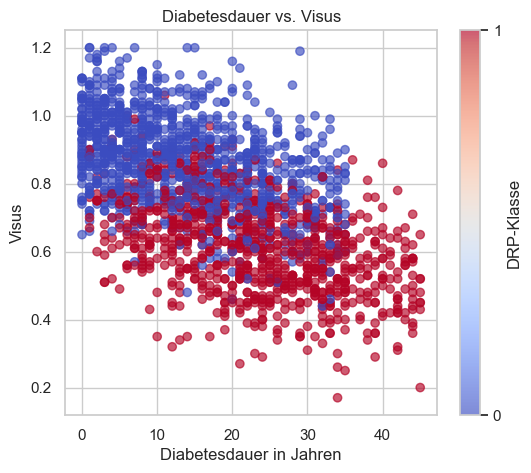

In [449]:
# ============================================
# Visualisierung 3: Diabetesdauer vs. Visus
# ============================================
plt.figure(figsize=(6,5))
scatter = plt.scatter(
    df["duration_dm"],
    df["visual_acuity"],
    c=df["drp"], # Farbe nach DRP-Klasse
    cmap="coolwarm", # Farbskala für 2 Klassen
    alpha=0.65
)
plt.title("Diabetesdauer vs. Visus")
plt.xlabel("Diabetesdauer in Jahren")
plt.ylabel("Visus")
plt.colorbar(scatter, ticks=[0, 1], label="DRP-Klasse") # Farbskala mit Klassen 0 und 1
plt.show()

<Figure size 800x600 with 0 Axes>

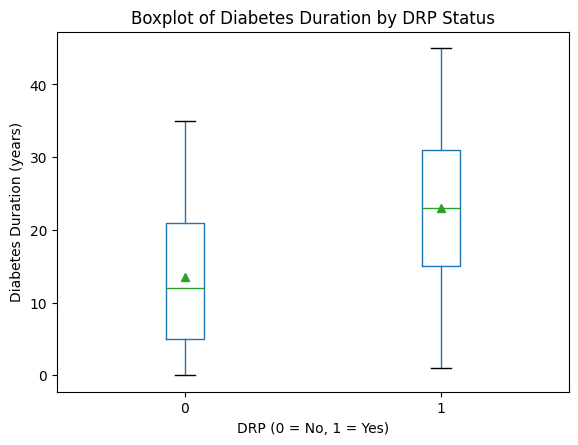

In [41]:
# -- This scatter plot shows a clear negative correlation between diabetes duration and visual acuity, with DRP-positive patients (in warmer colors) generally having lower visual acuity. This suggests that longer diabetes duration is associated with worse visual outcomes, especially in those with DRP.
plt.figure(figsize=(8, 6))
df.boxplot(column='duration_dm', by='drp', grid=False, showmeans=True)
plt.title("Boxplot of Diabetes Duration by DRP Status")
plt.suptitle("")  # Remove the default title
plt.xlabel("DRP (0 = No, 1 = Yes)")
plt.ylabel("Diabetes Duration (years)")
plt.show()

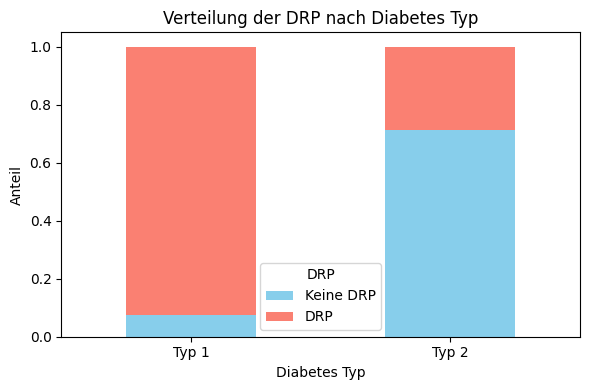

In [37]:
# ============================================
# Verteilung der DRP nach Diabetes Typ
# ============================================
drp_by_type = df.groupby("diabetes_type")["duration_dm"].value_counts(normalize=True).unstack()

drp_by_type.plot(kind="bar", stacked=True, figsize=(6, 4), color=["skyblue", "salmon"])
plt.title("Dauer der DM nach Diabetes Typ")
plt.ylabel("Anteil")
plt.xlabel("Diabetes Typ")
plt.legend(["Keine DRP", "DRP"], title="DRP")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Gruppendiskussion: HbA1c

**1.** Wie plausibel ist die beobachtete Beziehung zwischen Diabetesdauer und DRP aus klinischer Sicht?
    ### It makes sense, because with long term diabetes the damage on the vessels will get worse. 

**2.** Vergleiche Diabetesdauer und DRP zwischen Menschen mit Diabetes Typ 1 und 2. Was fällt dir auf? Inwiefern könnte das pathophysiologisch plausibel sein? 
- Pathophysio: Hypoxia, Neovascularisation, AGE-advance glykation end produkts, low compliance. 

**3.** Recherche: Welche klinischen Studien haben diesen Zusammenhang zum ersten Mal dargestellt? 1948



## Mini-Quiz 1

**1.** Ist `drp` in diesem Notebook ein Klassifikations- oder ein Regressions-Target? Klassifikationstarget. 
**2.** Warum ist eine Visualisierung vor dem Modelltraining sinnvoll? Evaluation of data distribution, quality. 
**3.** Welche Variablen in unserem Datensatz sind klinisch interpretierbar? Alle

> **Deine Antwort:**  
> Schreibe deine Antworten in die nächste Zelle.

In [450]:
# Schreibe hier deine Antworten zu Mini-Quiz 1 und der Gruppendiskussion.

# 3. Features und Target definieren

Für die Klassifikation verwenden wir dieselben Features wie später für die Regression.

- **Features `X`**
  - `age`
  - `hba1c`
  - `duration_dm`
  - `cholesterol`
  - `sbp`
  - `visual_acuity`
  - `metamorphopsia`
  - `diabetes_type`

- **Target für Klassifikation `y_class`**
  - `drp`

- **Target für Regression `y_reg`**
  - `retina_risk_score`

In [451]:
feature_cols = [
    "age", "hba1c", "duration_dm", "cholesterol",
    "sbp", "visual_acuity", "metamorphopsia", "diabetes_type"
]

X = df[feature_cols]
y_class = df["drp"]
y_reg = df["retina_risk_score"]

display(X.head())
display(y_class.head())
display(y_reg.head())

,age,hba1c,duration_dm,cholesterol,sbp,visual_acuity,metamorphopsia,diabetes_type
0,72,8.91,14,211.8,168.4,0.90,0,Typ 2
1,25,6.93,23,165.0,128.5,0.30,0,Typ 1
2,72,7.92,15,168.3,141.4,0.80,0,Typ 2
3,50,8.30,3,215.1,154.6,1.03,0,Typ 2
4,77,6.89,13,204.4,137.5,0.82,0,Typ 2


0    0
1    1
2    1
3    0
4    0
Name: drp, dtype: int64

0    58.66
1    89.68
2    55.48
3     7.50
4    44.61
Name: retina_risk_score, dtype: float64

# 4. `train_test_split`

`train_test_split` teilt den Datensatz in einen **Trainingssatz** und einen **Testsatz**.  
Das ist ein Standardwerkzeug im scikit-learn-Workflow. Der typische Ablauf besteht aus Modell instanziieren, `fit`, dann `predict`.

## Warum überhaupt splitten?

Wenn wir auf allen Daten trainieren und auf denselben Daten evaluieren, messen wir nur, wie gut sich das Modell die Trainingsdaten merken konnte.

Uns interessiert aber etwas anderes:

> Wie gut funktioniert das Modell auf neuen, ungesehenen Daten?

Darum teilen wir:

### Trainingsdaten
Mit diesen Daten lernt das Modell die Beziehung zwischen Features und Target.

### Testdaten
Diese Daten werden **nicht** zum Lernen verwendet.  
Sie dienen der ehrlichen Evaluation.

## Wichtige Parameter

### `test_size`
Bestimmt den Anteil des Testsatzes.  
Beispiel: `test_size=0.2` bedeutet 80 % Training und 20 % Test.

### `random_state`
Sorgt für Reproduzierbarkeit.  
Mit festem `random_state` ist der Split bei jedem Lauf identisch.

### `stratify=y`
Bei Klassifikation besonders wichtig.  
Dadurch bleibt das Klassenverhältnis in Train und Test ähnlich.

## Data Leakage vermeiden

Vorverarbeitung muss korrekt erfolgen.  
Skalierung oder Encoding darf nicht mit Informationen aus dem Testsatz „vorab gelernt“ werden. Ansonsten wird nur die Fährigkeit des Progrmmes getestet Bilder auswendig zu lernen.

In [452]:
# ============================================
# Train-Test-Split für Klassifikation
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class,
    test_size=0.3,
    random_state=42
    #stratify=y_class # stratifizierter Split, um Klassenverteilung in Train und Test zu erhalten
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nKlassenverteilung gesamt:")
print(y_class.value_counts(normalize=True).sort_index())

print("\nKlassenverteilung train:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nKlassenverteilung test:")
print(y_test.value_counts(normalize=True).sort_index())

X_train: (1400, 8)
X_test : (600, 8)
y_train: (1400,)
y_test : (600,)

Klassenverteilung gesamt:
drp
0    0.5455
1    0.4545
Name: proportion, dtype: float64

Klassenverteilung train:
drp
0    0.543571
1    0.456429
Name: proportion, dtype: float64

Klassenverteilung test:
drp
0    0.55
1    0.45
Name: proportion, dtype: float64


## Übungsblock 1 — ohne Lösung

Passe den Split an:

1. Setze `test_size=0.3`, # there is not much change
2. Entferne testweise `stratify=y_class`, there is not much changes
3. Vergleiche die Klassenverteilungen: keine Um-Klassenverteilung, bleibt ähnlich. 

**Frage:** Was verändert sich und warum ist das wichtig? Kein Overfitting, to avoid bias. 

In [453]:
# Übung: Verändere hier test_size und stratify und beobachte die Auswirkungen.



In [454]:
df["metamorphopsia"].value_counts()

metamorphopsia
0    1733
1     267
Name: count, dtype: int64

# 5. Kategoriale Variablen encoden und numerische Features skalieren

`diabetes_type` ist kategorial und muss numerisch encodiert werden.  
Für KNN ist außerdem Skalierung besonders wichtig, weil KNN auf Distanzen basiert. Wenn ein Feature eine viel größere Größenordnung hat als andere, beeinflusst es die Distanz unverhältnismäßig stark.

Wir verwenden:
- `OneHotEncoder` für `diabetes_type`
- `StandardScaler` für numerische Features
- `ColumnTransformer` und `Pipeline` für einen sauberen Workflow

In [455]:
numeric_features = [
    "age", "hba1c", 
    "duration_dm", "cholesterol","sbp", "visual_acuity", "metamorphopsia"
]
categorical_features = ["diabetes_type"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

# 6. KNN-Klassifikation

KNN steht für **k-Nearest Neighbors**.  
Für eine neue Beobachtung sucht das Modell die `k` nächstgelegenen Trainingspunkte und lässt diese abstimmen.

## Intuition
- kleines `k` → sehr flexibel
- großes `k` → glatter und robuster
- zu kleines `k` kann overfitten
- zu großes `k` kann underfitten

In [456]:
# ============================================
# Basismodell: KNN-Klassifikation
# ============================================
knn_clf = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=100))
])

knn_clf.fit(X_train, y_train)

y_pred = knn_clf.predict(X_test)
y_prob = knn_clf.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("ROC AUC :", round(roc_auc_score(y_test, y_prob), 3))
print("\nKlassifikationsbericht:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.867
ROC AUC : 0.943

Klassifikationsbericht:

              precision    recall  f1-score   support

           0       0.83      0.95      0.89       330
           1       0.92      0.77      0.84       270

    accuracy                           0.87       600
   macro avg       0.88      0.86      0.86       600
weighted avg       0.87      0.87      0.86       600



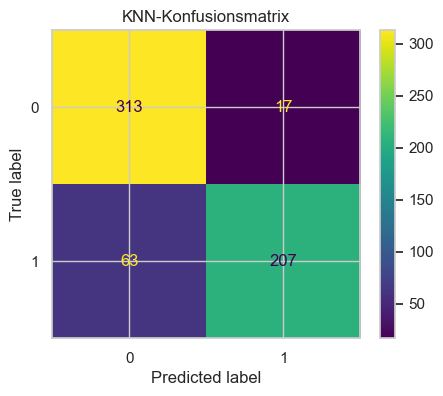

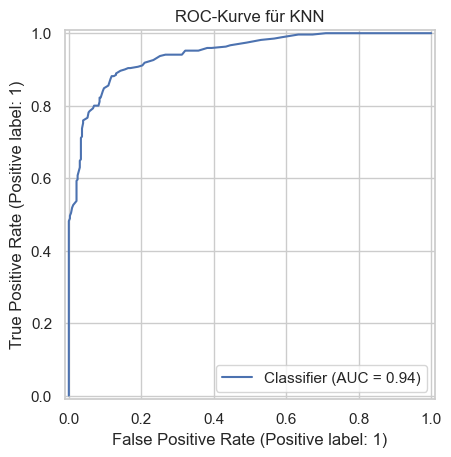

In [457]:
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
plt.title("KNN-Konfusionsmatrix")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC-Kurve für KNN")
plt.show()

## Gruppendiskussion: Detektion von Diabetischer Retinopathie

**1.** Ist Accuracy eine geeignete Metrik für die Evaluation eines DRP-Screenings?

**2.** Was wäre klinisch schlimmer: falsch-negativ (DRP übersehen oder falsch-positiv (unnötige Abklärung))

**3.** Welche Metrik wäre hier sinnvoller ?


## Mini-Quiz 2

**1.** Warum ist KNN empfindlich gegenüber unskalierten Features?  
**2.** Was bedeutet `k=9` in unserem Modell?  
**3.** Warum reicht Accuracy allein oft nicht aus?

> Antworte in der nächsten Zelle.

# Schreibe hier deine Antworten zu Gruppendiskussion.
1. Nein, Accuracy (Genauigkeit) ist hier nicht gut geeignet. Bei medizinischen Datensätzen, die oft unausgeglichen sind (z.B. viel mehr Gesunde als Kranke), kann eine hohe Accuracy täuschen. Wenn ein Modell einfach immer "gesund" vorhersagt, hat es bei 90% gesunden Patienten eine Accuracy von 90%, ohne einen einzigen Kranken gefunden zu haben. 
2. Falsch-negativ ist klinisch deutlich schlimmer. Wenn eine DRP übersehen wird, erhält der Patient keine Behandlung und kann im schlimmsten Fall erblinden. Ein falsch-positives Ergebnis führt zwar zu einer unnötigen Kontrolle beim Augenarzt (Kosten/Aufwand/Sorge), aber der Patient nimmt dadurch keinen irreversiblen körperlichen Schaden.
3. Da wir falsch-negative Ergebnisse unbedingt minimieren wollen, ist der Recall (Sensitivität) die wichtigste Metrik. Auch der F1-Score (harmonisches Mittel aus Precision und Recall) ist sehr nützlich, um eine gute Balance zu finden, wenn der Datensatz ungleichmäßig verteilt ist.

# Miniquiz 2:
1. KNN (K-Nearest Neighbors) berechnet Abstände (meist Euklidische Distanz) zwischen Datenpunkten. Wenn ein Feature sehr große Werte hat (z.B. Cholesterin um die 200) und ein anderes sehr kleine (z.B. HbA1c um die 8.0), dominiert das Feature mit den großen Zahlen die Distanzberechnung komplett, obwohl es vielleicht gar nicht so wichtig ist. Daher muss skaliert werden (Standardisierung).
2. Das bedeutet, dass das Modell bei einer neuen Vorhersage die 9 am nächsten liegenden Nachbarn (Patienten aus dem Trainingsset) betrachtet. Das Ergebnis wird dann durch eine Mehrheitsentscheidung (Voting) dieser 9 Nachbarn bestimmt.
3. Weil sie nicht zwischen der Art der Fehler unterscheidet (falsch-positiv vs. falsch-negativ) und bei unbalancierten Datensätzen eine gute Modell-Performance suggeriert, die in der Realität nicht existiert (siehe auch Antwort zu Frage 1 aus der DRP-Gruppendiskussion).

# 7. Overfitting und Underfitting mit KNN

Ein besonders anschauliches Beispiel für Modellkomplexität ist KNN:

- **sehr kleines `k`** → Modell reagiert stark auf einzelne Beobachtungen → Risiko von Overfitting
- **sehr großes `k`** → Modell mittelt zu stark → Risiko von Underfitting

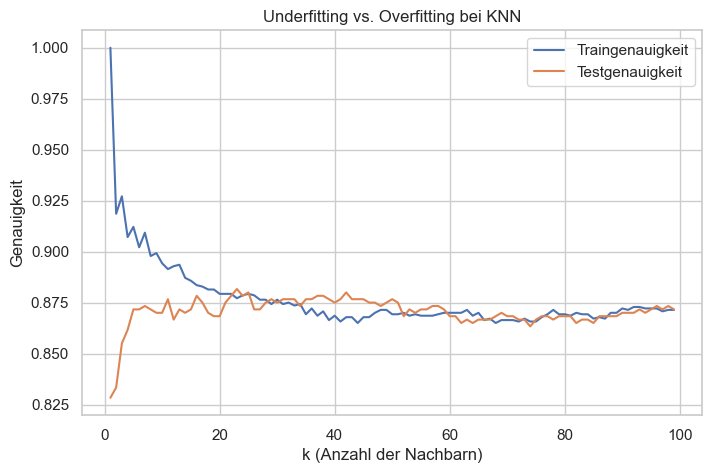

Bestes k auf Basis der Test-Accuracy in diesem Lauf: 23


In [458]:
# ============================================
# Trainings- und Testgenauigkeit für verschiedene k
# ============================================
k_values = range(1, 100)
train_scores = []
test_scores = []

for k in k_values:
    pipe = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=k))
    ])
    pipe.fit(X_train, y_train)
    train_scores.append(pipe.score(X_train, y_train))
    test_scores.append(pipe.score(X_test, y_test))

plt.figure(figsize=(8,5))
plt.plot(k_values, train_scores, label="Traingenauigkeit")
plt.plot(k_values, test_scores, label="Testgenauigkeit")
plt.xlabel("k (Anzahl der Nachbarn)")
plt.ylabel("Genauigkeit")
plt.title("Underfitting vs. Overfitting bei KNN")
plt.legend()
plt.show()

best_k = list(k_values)[int(np.argmax(test_scores))]
print("Bestes k auf Basis der Test-Accuracy in diesem Lauf:", best_k)

> **Interpretation**  
> Bei `k=1` ist die Trainingsgenauigkeit oft sehr hoch, weil das Modell sich lokale Strukturen fast „merkt“.  
> Bei sehr großem `k` wird das Modell zu grob und verliert wichtige Struktur.  
> Gute Generalisierung liegt oft in einem mittleren Bereich.

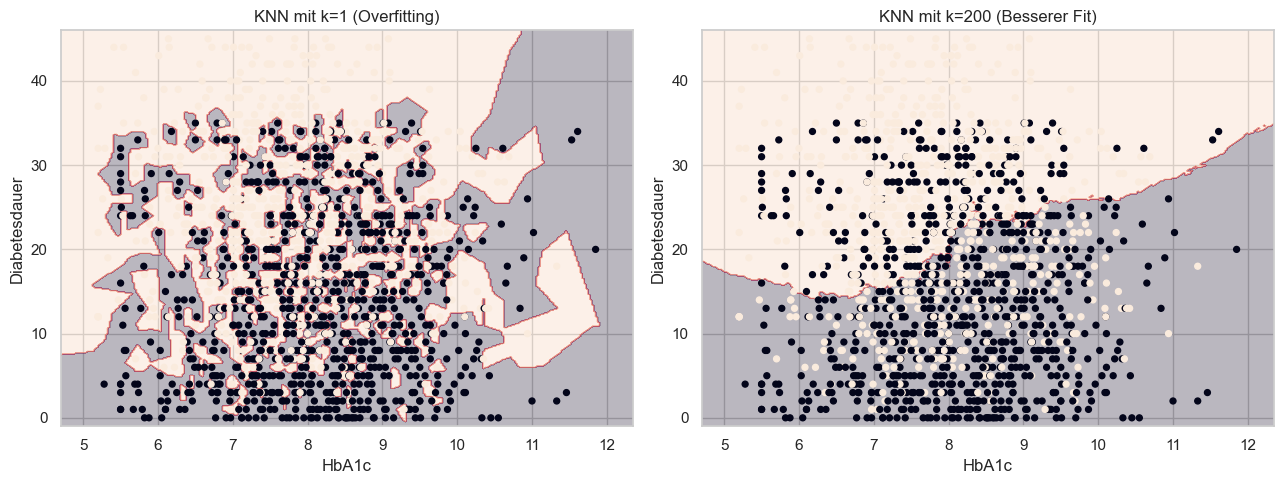

In [459]:
# ============================================
# 2D-Visualisierung der Entscheidungsgrenzen
# ============================================
features_2d = ["hba1c", "duration_dm"]
X2 = df[features_2d]
y2 = df["drp"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

pipe_k1 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=1))
])

pipe_k35 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=200))
])

pipe_k1.fit(X2_train, y2_train)
pipe_k35.fit(X2_train, y2_train)

x_min, x_max = X2["hba1c"].min() - 0.5, X2["hba1c"].max() + 0.5
y_min, y_max = X2["duration_dm"].min() - 1, X2["duration_dm"].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)
grid = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=features_2d)

Z1 = pipe_k1.predict(grid).reshape(xx.shape)
Z35 = pipe_k35.predict(grid).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(13,5))

axes[0].contourf(xx, yy, Z1, alpha=0.3)
axes[0].scatter(X2_train["hba1c"], X2_train["duration_dm"], c=y2_train, s=18)
axes[0].set_title("KNN mit k=1 (Overfitting)")
axes[0].set_xlabel("HbA1c")
axes[0].set_ylabel("Diabetesdauer")

axes[1].contourf(xx, yy, Z35, alpha=0.3)
axes[1].scatter(X2_train["hba1c"], X2_train["duration_dm"], c=y2_train, s=18)
axes[1].set_title("KNN mit k=200 (Besserer Fit)")
axes[1].set_xlabel("HbA1c")
axes[1].set_ylabel("Diabetesdauer")

plt.tight_layout()
plt.show()

## Übungsblock 2 — ohne Lösung

Teste:
- `k=1`
- `k=100`
- `k=800`
- `k=1399`

**Fragen:**
1. Welches Modell wirkt overfitted?
2. Welches Modell wirkt underfitted?
3. Schaue dir die `confusion_matrix` und den `classification report` von einem beliebigen k an. Welche Metrik wäre dir in der Praxis am wichtigsten?
4. In welchem Bereich vermutest du die beste Generalisierung? Finde es heraus!

In [460]:
# Übung: Teste hier verschiedene Werte für k und vergleiche Train- und Test-Accuracy.




# 8. Regression

Jetzt sagen wir keinen Klassenwert, sondern einen **kontinuierlichen Wert** vorher: `retina_risk_score`.

Wir beginnen mit einer **linearen Regression**.

## Idee
Ein lineares Modell beschreibt das Target als lineare Kombination der Features:
- jedes Feature erhält einen Koeffizienten
- positive Koeffizienten erhöhen die Vorhersage
- negative Koeffizienten senken sie

Lineare Regression ist oft eine gute, interpretierbare Baseline.

In [461]:
# ============================================
# Train-Test-Split für Regression
# ============================================
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

linreg = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", LinearRegression())
])

linreg.fit(X_train_r, y_train_r)

pred_r = linreg.predict(X_test_r)

mae = mean_absolute_error(y_test_r, pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, pred_r))
r2 = r2_score(y_test_r, pred_r)

print("Lineare Regression")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 3))

Lineare Regression
MAE : 4.88
RMSE: 5.98
R²  : 0.973


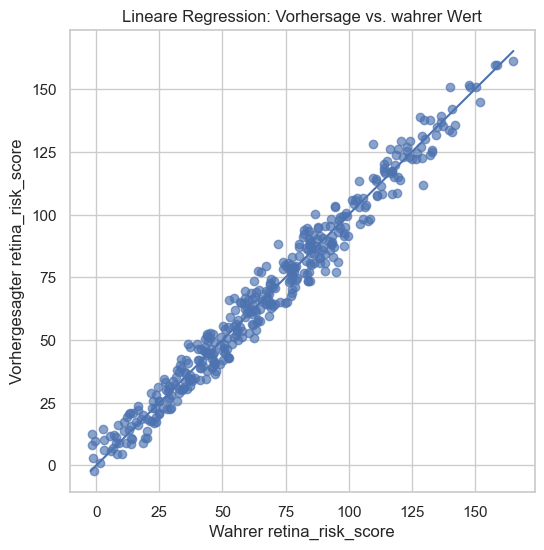

In [462]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_r, pred_r, alpha=0.65)
lims = [
    min(y_test_r.min(), pred_r.min()),
    max(y_test_r.max(), pred_r.max())
]
plt.plot(lims, lims)
plt.xlabel("Wahrer retina_risk_score")
plt.ylabel("Vorhergesagter retina_risk_score")
plt.title("Lineare Regression: Vorhersage vs. wahrer Wert")
plt.show()

## Mini-Quiz 3

**1.** Was ist der Unterschied zwischen Klassifikation und Regression?  
**2.** Was sagt ein hoher `R²`-Wert aus?

**3.** Was bedeuten RMSE und MAE? Wann könnte MAE und wann könnte RMSE eine bessere Option sein?  
**4.** Warum ist lineare Regression oft ein guter Startpunkt vor der Auswahl komplexer Modelle?

> Antworte in der nächsten Zelle.

# Schreibe hier deine Antworten zu Mini-Quiz 3.

2. Das Bestimmtheitsmaß (R²) gibt an, wie gut ein Regressionsmodell die Varianz der abhängigen (vorherzusagenden) Variable durch die unabhängigen Variablen (Features) erklären kann. Ein hoher R²-Wert (nahe 1,0 oder 100%) bedeutet, dass das Modell die historischen Daten sehr gut beschreibt und ein großer Teil der Streuung erklärt wird. Beispielsweise bedeutet ein R² von 0,85, dass 85% der Schwankungen in den Daten durch das Modell erklärt werden. Achtung: Ein hoher R²-Wert bedeutet nicht zwingend, dass das Modell gute Vorhersagen für neue Daten macht (Overfitting) oder dass ein kausaler Zusammenhang besteht. Fügt man einem Modell irrelevante Variablen hinzu, kann das R² sogar künstlich steigen, weshalb oft das adjustierte R² herangezogen wird.


3. Der RMSE (Root Mean Squared Error) ist die Wurzel aus dem Durchschnitt der quadrierten Fehler, während der MAE (Mean Absolute Error) den Durchschnitt der absoluten Abweichungen zwischen Vorhersage und echten Werten darstellt. Da der RMSE die Fehler vor dem Durchschnittbilden quadriert, bestraft er große Fehler (Ausreißer) viel stärker als kleine Abweichungen.

Wann MAE besser ist: MAE ist robuster und sollte bevorzugt werden, wenn der Datensatz Ausreißer enthält, die die Modellbewertung nicht unverhältnismäßig dominieren sollen. Er beschreibt den "typischen" durchschnittlichen Fehler gut.

Wann RMSE besser ist: RMSE eignet sich, wenn man große Fehler unter allen Umständen vermeiden möchte und diese das Modell stark "bestrafen" sollen. RMSE ist zudem oft die Standardwahl, wenn man annimmt, dass die Fehler normalverteilt sind.

4. Gute Interpretierbarkeit. 


# 9. KNN-Regressor

Dasselbe Grundprinzip von KNN lässt sich auch für Regression einsetzen.

- **KNeighborsClassifier** → Nachbarn stimmen über Klassen ab
- **KNeighborsRegressor** → Nachbarn mitteln einen kontinuierlichen Zielwert

In [463]:
knn_reg = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", KNeighborsRegressor(n_neighbors=15))
])

knn_reg.fit(X_train_r, y_train_r)
pred_knn_r = knn_reg.predict(X_test_r)

print("KNN Regressor")
print("MAE :", round(mean_absolute_error(y_test_r, pred_knn_r), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test_r, pred_knn_r)), 2))
print("R²  :", round(r2_score(y_test_r, pred_knn_r), 3))

KNN Regressor
MAE : 8.32
RMSE: 10.42
R²  : 0.919


# 10. Ridge und Lasso

Nun betrachten wir zwei regularisierte lineare Modelle.

## Ridge
Ridge nutzt **L2-Regularisierung**.  
Die Koeffizienten werden geschrumpft, aber typischerweise nicht auf exakt null gesetzt.

## Lasso
Lasso nutzt **L1-Regularisierung**.  
Das Modell kann manche Koeffizienten auf **genau null** setzen und wirkt dadurch sparsamer.

> **Merke**  
> Regularisierung hilft oft dann, wenn Daten verrauscht sind oder wenn Features teilweise redundant sind.

In [464]:
ridge = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", Ridge(alpha=10.0))
])

lasso = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", Lasso(alpha=10.0))
])

ridge.fit(X_train_r, y_train_r)
lasso.fit(X_train_r, y_train_r)

pred_ridge = ridge.predict(X_test_r)
pred_lasso = lasso.predict(X_test_r)

results = pd.DataFrame({
    "Modell": ["LinearRegression", "Ridge(alpha=1.0)", "Lasso(alpha=0.1)", "KNNRegressor(k=15)"],
    "MAE": [
        mean_absolute_error(y_test_r, pred_r),
        mean_absolute_error(y_test_r, pred_ridge),
        mean_absolute_error(y_test_r, pred_lasso),
        mean_absolute_error(y_test_r, pred_knn_r)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test_r, pred_r)),
        np.sqrt(mean_squared_error(y_test_r, pred_ridge)),
        np.sqrt(mean_squared_error(y_test_r, pred_lasso)),
        np.sqrt(mean_squared_error(y_test_r, pred_knn_r))
    ],
    "R2": [
        r2_score(y_test_r, pred_r),
        r2_score(y_test_r, pred_ridge),
        r2_score(y_test_r, pred_lasso),
        r2_score(y_test_r, pred_knn_r)
    ]
})

results.round(3)

,Modell,MAE,RMSE,R2
0,LinearRegression,4.877,5.980,0.973
1,Ridge(alpha=1.0),4.873,5.988,0.973
2,Lasso(alpha=0.1),9.408,11.595,0.900
3,KNNRegressor(k=15),8.315,10.422,0.919


In [465]:
feature_names = ridge.named_steps["prep"].get_feature_names_out()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "linear": linreg.named_steps["model"].coef_,
    "ridge": ridge.named_steps["model"].coef_,
    "lasso": lasso.named_steps["model"].coef_
})

coef_df

,feature,linear,ridge,lasso
0,num__age,-0.021918,0.285377,0.000000
1,num__hba1c,1.657487,1.638499,0.000000
2,num__duration_dm,35.949937,35.475515,27.861028
3,num__cholesterol,1.475975,1.435429,0.000000
4,num__sbp,1.696607,1.650467,0.000000
5,num__visual_acuity,-3.054233,-3.243625,-0.000000
6,num__metamorphopsia,1.869910,1.880860,0.000000
7,cat__diabetes_type_Typ 2,-2.053518,-2.461904,-0.000000


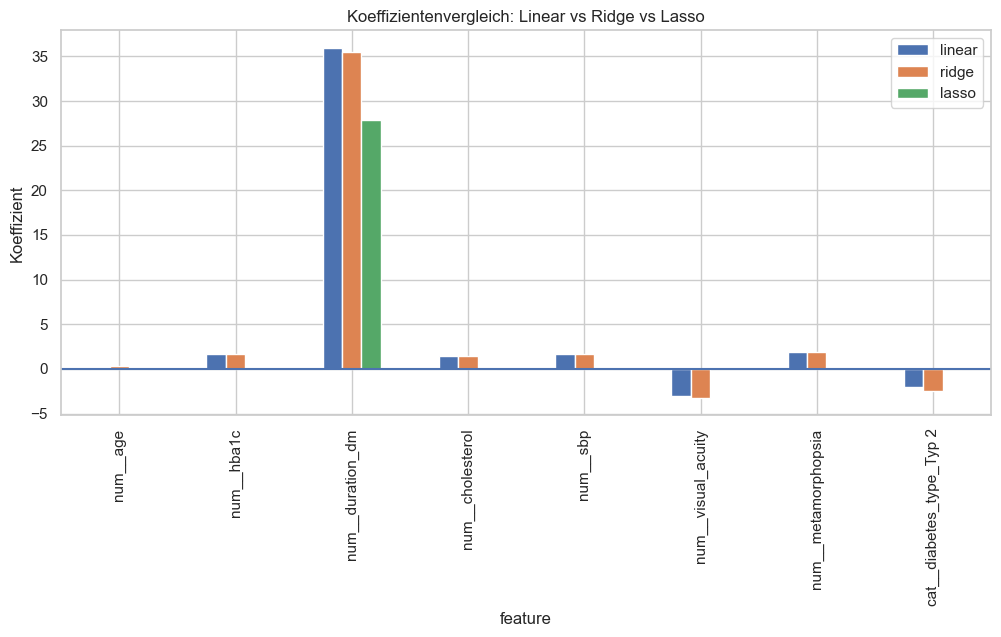

In [466]:
coef_plot = coef_df.set_index("feature")

coef_plot.plot(kind="bar", figsize=(12,5))
plt.title("Koeffizientenvergleich: Linear vs Ridge vs Lasso")
plt.ylabel("Koeffizient")
plt.axhline(0)
plt.show()

## Übungsblock 3 — ohne Lösung

Teste verschiedene Regularisierungsstärken:

- `alpha = 0.01`
- `alpha = 0.1`
- `alpha = 1.0`
- `alpha = 10.0`

**Fragen:**
1. Was passiert mit den Koeffizienten bei Ridge?
2. Was passiert mit den Koeffizienten bei Lasso?
3. Welche Modelle werden sparsamer?
4. Wie kann man den Effekt von alpha auf den Koeffizienten von `num_duration_dm` am besten graphisch darstellen?
5. Was ist das beste alpha für eine Ridgeregression?

In [467]:
# Hier Antworttext hinschreiben

# 11. Zusammenfassung

In diesem Notebook hast du gesehen:

1. supervised learning nutzt bekannte Zielwerte
2. es gibt Klassifikation und Regression
3. saubere Datenexploration ist der erste methodische Schritt
4. `train_test_split` trennt Lernen und ehrliche Evaluation
5. KNN eignet sich hervorragend, um Underfitting und Overfitting zu demonstrieren
6. lineare Regression ist eine starke, interpretierbare Baseline
7. Ridge und Lasso regularisieren lineare Modelle

> **Abschluss-Merksatz**  
> Erst Daten verstehen.  
> Dann sauber splitten.  
> Dann modellieren.  
> Dann ehrlich evaluieren.

# 12. Abschluss-Quiz

Beantworte die folgenden Fragen in eigenen Worten:

1. Warum ist `stratify=y` bei Klassifikation oft sinnvoll?
2. Warum ist KNN besonders anfällig für schlechte Skalierung?
3. Woran erkennst du Overfitting in einer Train-vs-Test-Kurve?
4. Was ist der Unterschied zwischen Ridge und Lasso?
5. Warum ist ein interpretierbares Basismodell in der Medizin oft wertvoll?

>  Schreibe deine Antworten unten.

In [468]:
# Hier kannst du deinen Antworttext hinschreiben

# Gedankenexperiment

Stellen Sie sich vor, sie wären Augenarzt*ärztin in einer ländlichen unterversorgten Region und möchten eines der Modelle benutzen, um Überweisungen von Hausärzten zum Screening bei Diabetischer Retinopathie zu priorisieren.

Fragen:

**1.** Welche Validierungsschritte fehlen noch?

**2.** Welche Bias-Risiken wären besonders relevant?

**3.** Welche Verantwortung bleibt trotz Modell beim ärztlichen Team?

**4.** Würden Sie selbst so ein Modell benutzen?

In [469]:
# Hier kannst du deinen Antworttext hinschreiben

Questions: 
1. Metamorphopsie: binomial, no need to scale and out from the numeric features. Gibt es einen bestimmten Grund, warum wir metamorphopsia standardisieren und nicht einfach per passthrough durchreichen? Bei binären Features bringt uns das Scaling ja eigentlich keinen Informationsgewinn."
2. Visual acuity and metamorphopsie inhaltliche zusammenhang: deswegen regularisierung
3. Negative Risiko score, how does it make sense
4. Risiko correlation with the dauer_dm? Dauer_dm ganz raus nehmen??? 
